<a href="https://colab.research.google.com/github/asmita-durugkar/ml_learning/blob/main/pumpkin_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url='https://raw.githubusercontent.com/microsoft/ML-For-Beginners/refs/heads/main/2-Regression/data/US-pumpkins.csv'
df = pd.read_csv(url)
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [5]:
df.isnull().sum()
selected_coulmns=['Package','Low Price','High Price','Date']
df=df.loc[:,selected_coulmns]
df


,Package,Low Price,High Price,Date
0,24 inch bins,270.00,280.00,4/29/17
1,24 inch bins,270.00,280.00,5/6/17
2,24 inch bins,160.00,160.00,9/24/16
3,24 inch bins,160.00,160.00,9/24/16
4,24 inch bins,90.00,100.00,11/5/16
...,...,...,...,...
1752,22 lb cartons,14.75,14.75,9/30/16
1753,36 inch bins,275.00,275.00,9/26/16
1754,36 inch bins,275.00,275.00,9/27/16
1755,36 inch bins,275.00,275.00,9/28/16


In [6]:
# 1. Filter out the bins/boxes immediately into a new dataframe
price_lb = df[df['Package'].str.contains('lb', case=False, na=False)].copy()

# 2. Calculate the average price and extract the month strictly using the filtered rows
price_for_lb = (price_lb['Low Price'] + price_lb['High Price']) / 2
month_for_lb = pd.DatetimeIndex(price_lb['Date']).month

# 3. Extract the numeric values from the package text (e.g., "22" from "22 lb cartons")
price_lb['wt_lbs'] = price_lb['Package'].str.extract(r'(\d+)').astype(float)

# 4. Convert pounds to Kilograms
price_lb['wt_kgs'] = price_lb['wt_lbs'] * 0.453592

# 5. Calculate price per kg using the matching filtered lengths
price_lb['price_per_kg'] = price_for_lb / price_lb['wt_kgs']

# 6. Build your final clean dataframe using only the filtered data sources
new_df = pd.DataFrame({
    'Month': month_for_lb,
    'Package': price_lb['Package'],
    'Low Price': price_lb['Low Price'],
    'High Price': price_lb['High Price'],
    'Price per kg': price_lb['price_per_kg'],
    'weight_kg': price_lb['wt_kgs']
})

# Display the clean dataframe
new_df

,Month,Package,Low Price,High Price,Price per kg,weight_kg
45,8,50 lb sacks,29.00,29.00,1.278682,22.679600
46,8,50 lb sacks,29.00,29.00,1.278682,22.679600
47,8,50 lb sacks,28.00,29.00,1.256636,22.679600
48,8,50 lb sacks,28.00,29.00,1.256636,22.679600
49,8,50 lb sacks,29.00,29.00,1.278682,22.679600
...,...,...,...,...,...,...
1748,9,22 lb cartons,14.75,14.75,1.478100,9.979024
1749,9,22 lb cartons,10.75,10.75,1.077260,9.979024
1750,9,22 lb cartons,14.75,14.75,1.478100,9.979024
1751,9,22 lb cartons,10.75,10.75,1.077260,9.979024


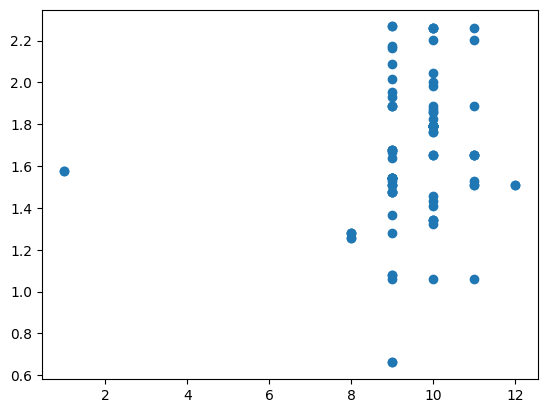

In [8]:
plt.scatter(new_df['Month'],new_df['Price per kg'])# not useful use another chart
plt.show()

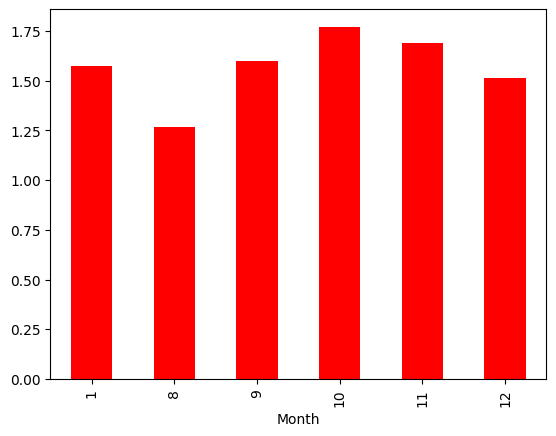

In [11]:
new_df.groupby('Month')['Price per kg'].mean().plot(kind='bar',color='red')
plt.show()
